## Conclusions

This section summarizes the exploratory data analysis performed on the Jigsaw Toxic Comment dataset after mapping it into a unified moderation schema (safe, toxicity, hate). The goal is to understand dataset characteristics, distributional biases, and modeling implications before training the first model.

### Label Distribution

The dataset shows strong class imbalance, especially for the hate category:

| Label      | Count   | Percentage |
| ---------- | ------- | ---------- |
| Toxicity=1 | 16,171  | ~10%       |
| Hate=1     | 1,405   | <1%        |
| Safe=1     | 143,346 | ~89%       |

**Implications:**
- Both class weighting and stratified sampling will be required. Plus maybe more advanced techniques (SMOTE, etc).
- Accuracy could be misleading, evaluations must use ROC-AUC, F1-score, confusion matrices, etc.

### Text Characteristics

**Text Length:**
- Distributions is heavily skewed, so the majority of the texts are short.
- Majority of examples (99.95%) fit within 256 tokens, so max_length=256 is feasible for BERT without significant truncation.

**Domain Characteristics:**
- The most common n-grams are:
    - article, wikipedia, page, talk

This confirms the dataset comes from Wikipedia talk pages

**Implications:**
- Model may not generalize so well to more informal or meme-style content.
- Additional data would be required for broader coverage.

### Lexical Bias Analysis

Identity-related words were examined for disproportionate association with toxic/hate labels.

| Term   | Safe  | Toxic | Hate  |
| ------ | ----- | ----- | ----- |
| black  | 0.860 | 0.136 | 0.036 |
| white  | 0.870 | 0.127 | 0.036 |
| muslim | 0.874 | 0.120 | 0.060 |
| jew    | 0.818 | 0.171 | 0.089 |
| gay    | 0.431 | 0.558 | 0.287 |
| asian  | 0.880 | 0.114 | 0.052 |


**Observations:**
- Some terms correlate disproportionately with toxic/hate labels.
- "gay" shows a particularly high association with toxic and hateful labels.
- This could reflect a dataset bias rather than actual content patterns.

**Implications:**
- A model trained on this data may over-penalize the mention of these terms even in neutral contexts.
- A fairness mitigation strategy (counterfactual data augmentation, bias regularization) is needed to prevent unintended discrimination.

### Analysis

Profanity and slur keywords were analyzed for their correlation with labels. 

| Keyword            | Safe    | Toxic  | Hate |
| ------------------ | ------- | ------ | ---- |
| *profanity 1*      | 0.001   | 0.264  | 1.00 |
| *profanity 2*      | 0.0004  | 0.053  | 1.00 |
| *profanity 3*      | 0.0003  | 0.041  | 1.00 |
| *slur 1*           | 0.00027 | 0.0136 | 1.00 |
| *slur 2*           | 0.00204 | 0.0024 | 1.00 |
| *slur 3*           | 0.00010 | 0.030  | 1.00 |


**Observations:**
- Slur tokens are perfect predictors of the hate label in this dataset.
- The model may learn shortcut features (e.g., "if slur -> hate").
- It may fail to detect implicit or coded hate without explicit slurs.

**Implications:**
- Additional datasets with subtle/non-explicit hate content are needed.
- Multimodal datasets (Hateful Memes, MMHS150K) will help.



### Label Noise Exploration

318 samples were flagged as potentially noisy, using checks such as:
- hate=1 but toxicity=0
- safe=1 but containing profanity
- Unusually short or long texts
- Duplicates

**Observations:**
- Label noise is present but manageable.
- Some toxicity/hate cases involve sarcasm, quotes, or ambiguous contexts.

**Implications:**
- Consider label smoothing or robust loss functions.
- In future, integrate CleanLab or confident learning approaches.

## Code

In [ ]:
import pandas as pd
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import re

plt.style.use("ggplot")

In [ ]:
# Loading local list of sensitive words to avoid exposing them on github

SENSITIVE_CFG_PATH = Path("../config/local_sensitive_words.json")

with open(SENSITIVE_CFG_PATH) as f:
    sensitive_cfg = json.load(f)

groups = sensitive_cfg.get("groups", [])
profane_words = sensitive_cfg.get("profane_words", [])
slurs = sensitive_cfg.get("slurs", [])


In [ ]:
DATA_PATH = Path('../data/preprocessed/text/jigsaw_unified.csv')
assert DATA_PATH.exists(), f"{DATA_PATH} not found"

In [ ]:
df = pd.read_csv(DATA_PATH)
df.head()

,text,toxicity,hate,safe
0,Explanation\nWhy the edits made under my usern...,0,0,1
1,D'aww! He matches this background colour I'm s...,0,0,1
2,"Hey man, I'm really not trying to edit war. It...",0,0,1
3,"""\nMore\nI can't make any real suggestions on ...",0,0,1
4,"You, sir, are my hero. Any chance you remember...",0,0,1


In [28]:
print("Shape:", df.shape)

print("\nColumns:", df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values per column:")
print(df.isna().sum())

Shape: (159571, 4)

Columns: ['text', 'toxicity', 'hate', 'safe']

Data types:
text        object
toxicity     int64
hate         int64
safe         int64
dtype: object

Missing values per column:
text        0
toxicity    0
hate        0
safe        0
dtype: int64


In [ ]:
total_rows = df.shape[0]

toxicity_rows = df[df["toxicity"] == 1].shape[0]
hate_rows = df[df["hate"] == 1].shape[0]
safe_rows = df[df["safe"] == 1].shape[0]

print(f"Proportion of samples with toxicity label: {toxicity_rows/total_rows}")
print(f"Proportion of samples with hate label: {hate_rows/total_rows}")
print(f"Proportion of samples with safe label: {safe_rows/total_rows}")


Proportion of samples with toxicity label: 0.10134046913286249
Proportion of samples with hate label: 0.00880485802558109
Proportion of samples with safe label: 0.8983211235124177


In [30]:
# Check unique values for label columns
label_cols = ["toxicity", "hate", "safe"]

for col in label_cols:
    print(f"\n{col} value counts:")
    print(df[col].value_counts(dropna=False))



toxicity value counts:
toxicity
0    143400
1     16171
Name: count, dtype: int64

hate value counts:
hate
0    158166
1      1405
Name: count, dtype: int64

safe value counts:
safe
1    143346
0     16225
Name: count, dtype: int64


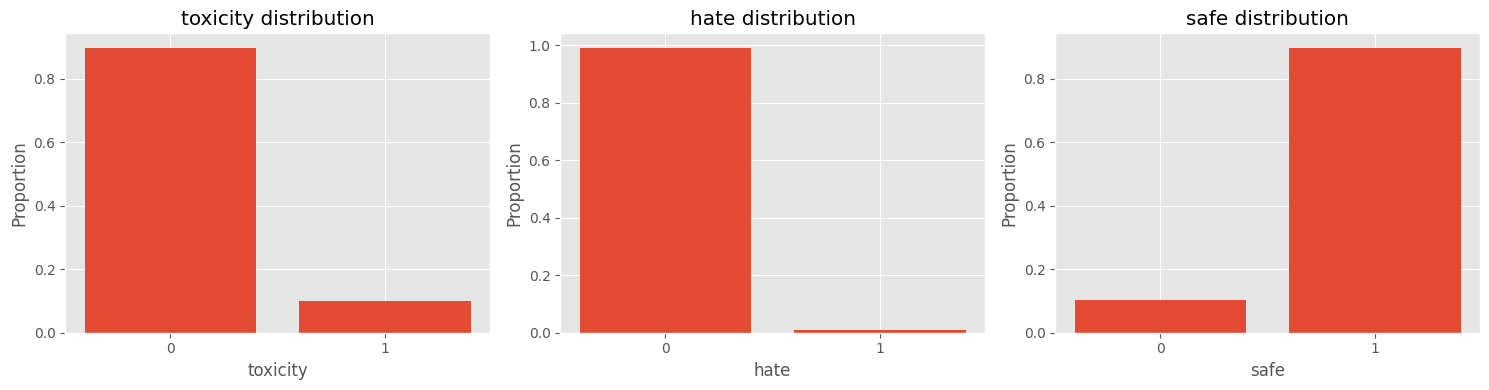

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, label_cols):
    vc = df[col].value_counts(normalize=True).sort_index()
    ax.bar(vc.index.astype(str), vc.values)
    ax.set_title(f"{col} distribution")
    ax.set_xlabel(col)
    ax.set_ylabel("Proportion")

plt.tight_layout()
plt.show()


In [ ]:
# Character length
df["text_len_char"] = df["text"].astype(str).str.len()

# Rough approximation separating by spaces
df["text_len_tokens"] = df["text"].astype(str).str.split().str.len()

df[["text_len_char", "text_len_tokens"]].describe()


,text_len_char,text_len_tokens
count,159571.000000,159571.000000
mean,394.073221,67.273527
std,590.720282,99.230702
min,6.000000,1.000000
25%,96.000000,17.000000
50%,205.000000,36.000000
75%,435.000000,75.000000
max,5000.000000,1411.000000


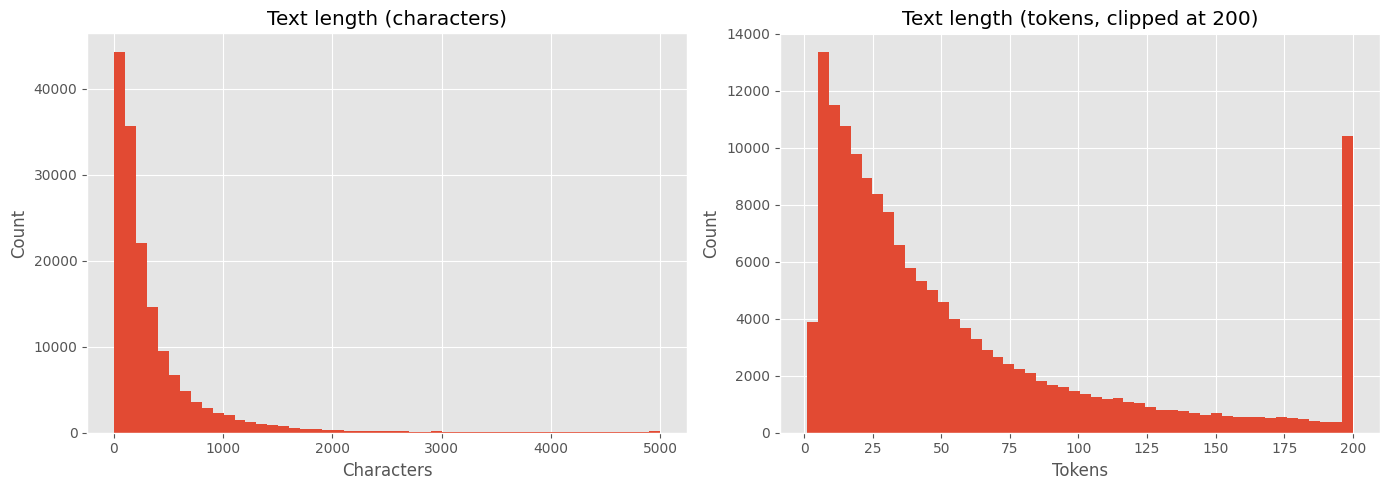

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Character length
axes[0].hist(df["text_len_char"], bins=50)
axes[0].set_title("Text length (characters)")
axes[0].set_xlabel("Characters")
axes[0].set_ylabel("Count")

# Token length (clip extreme long ones to make plot readable)
max_tokens_for_plot = 200
lengths = df["text_len_tokens"].clip(upper=max_tokens_for_plot)

axes[1].hist(lengths, bins=50)
axes[1].set_title(f"Text length (tokens, clipped at {max_tokens_for_plot})")
axes[1].set_xlabel("Tokens")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


In [34]:
percentiles = [50, 75, 90, 95, 99]
p_values = np.percentile(df["text_len_tokens"], percentiles)

for p, v in zip(percentiles, p_values):
    print(f"{p}th percentile: {v:.1f} tokens")

# Quick check: % of samples <= 128 / 256 tokens
for max_len in [64, 128, 256]:
    pct = (df["text_len_tokens"] <= max_len).mean() * 100
    print(f"{pct:.2f}% of samples have <= {max_len} tokens")


50th percentile: 36.0 tokens
75th percentile: 75.0 tokens
90th percentile: 152.0 tokens
95th percentile: 230.0 tokens
99th percentile: 567.0 tokens
70.52% of samples have <= 64 tokens
87.33% of samples have <= 128 tokens
95.95% of samples have <= 256 tokens


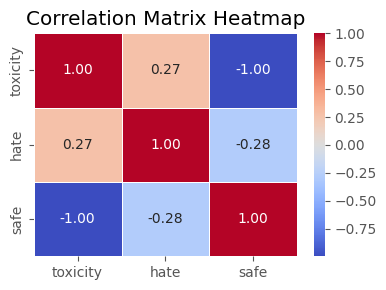

hate,0,1
toxicity,,
0,0.898321,0.000338
1,0.092874,0.008466


In [54]:
corr = df[label_cols].corr()

plt.figure(figsize=(4,3))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    cbar=True
)
plt.title("Correlation Matrix Heatmap")
plt.tight_layout()
plt.show()

# Simple crosstab
pd.crosstab(df["toxicity"], df["hate"], normalize="all")


In [37]:
# Empty or whitespace-only texts
empty_mask = df["text"].astype(str).str.strip().eq("")
print("Empty/whitespace texts:", empty_mask.sum())

# Duplicates
dup_mask = df["text"].duplicated()
print("Duplicate texts:", dup_mask.sum())

# Optionally inspect some
if empty_mask.any():
    print("\nSample empty rows:")
    display(df[empty_mask].head())

if dup_mask.any():
    print("\nSample duplicate rows:")
    display(df[dup_mask].head())


Empty/whitespace texts: 0
Duplicate texts: 0


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngrams(texts, n=10, ngram_range=(1,2)):
    cv = CountVectorizer(ngram_range=ngram_range, stop_words="english")
    X = cv.fit_transform(texts)
    freqs = zip(cv.get_feature_names_out(), X.sum(axis=0).A1)
    return sorted(freqs, key=lambda x: x[1], reverse=True)[:n]

print("Top n-grams in toxic:")
get_top_ngrams(df[df.toxicity==1]["text"], n=1)

print("\nTop n-grams in hate:")
get_top_ngrams(df[df.hate==1]["text"], n=15)

print("\nTop n-grams in safe:")
get_top_ngrams(df[df.safe==1]["text"], n=15)


Top n-grams in toxic:

Top n-grams in hate:

Top n-grams in safe:


[('article', np.int64(56088)),
 ('wikipedia', np.int64(44496)),
 ('page', np.int64(44081)),
 ('talk', np.int64(35552)),
 ('just', np.int64(25083)),
 ('like', np.int64(24201)),
 ('don', np.int64(20690)),
 ('think', np.int64(18687)),
 ('edit', np.int64(17231)),
 ('know', np.int64(16774)),
 ('people', np.int64(16400)),
 ('articles', np.int64(16156)),
 ('use', np.int64(16082)),
 ('time', np.int64(14698)),
 ('did', np.int64(13780))]

Batches: 100%|██████████| 63/63 [00:44<00:00,  1.40it/s]


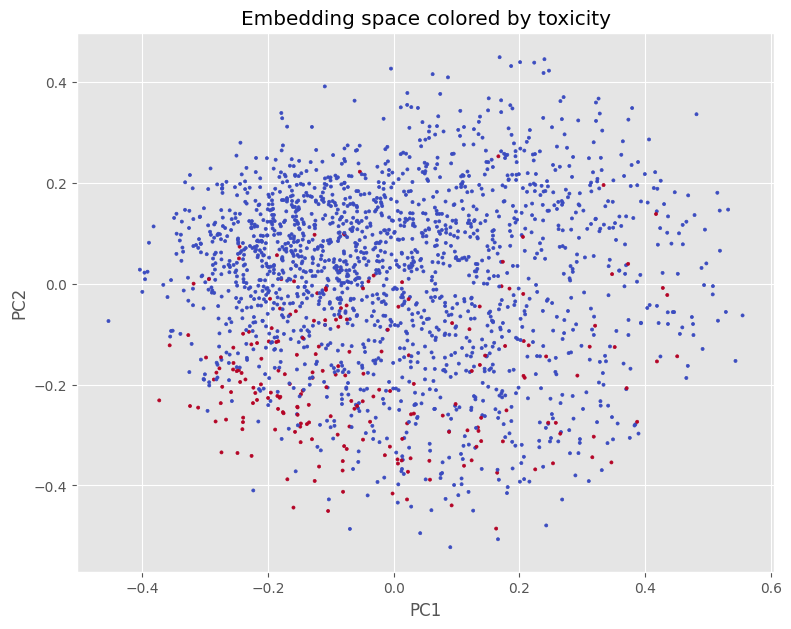

In [60]:
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA

model = SentenceTransformer("all-MiniLM-L6-v2")

sample = df.sample(2000).reset_index(drop=True)
emb = model.encode(sample["text"], show_progress_bar=True)

pca = PCA(n_components=2)
coords = pca.fit_transform(emb)

plt.figure(figsize=(9, 7))
plt.scatter(coords[:,0], coords[:,1], c=sample["toxicity"], cmap="coolwarm", s=5)
plt.title("Embedding space colored by toxicity")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


### REVIEW AND CLEAR OUTPUTS FOR SENSITIVE WORDS BEFORE COMMITING


In [ ]:
def show_examples(filter_cond, n=5, title="Examples"):
    print(f"\n===== {title} (n={n}) =====")
    subset = df[filter_cond].sample(min(n, filter_cond.sum()), random_state=42)
    for i, row in subset.iterrows():
        print(f"\n--- id={i} ---")
        print(f"toxicity={row['toxicity']} hate={row['hate']} safe={row['safe']}")
        print(row["text"])

# Safe
show_examples(df["safe"] == 1, n=5, title="Safe examples")

# Toxic but not hate
show_examples((df["toxicity"] == 1) & (df["hate"] == 0), n=5, title="Toxic (non-hate) examples")

# Hate
show_examples(df["hate"] == 1, n=5, title="Hate examples")


In [ ]:
# Lexical bias analysis

for group in groups:
    mask = df["text"].str.contains(group, case=False, regex=False)
    print(f"{group}: "
          f"safe={df[mask]['safe'].mean():.3f}, "
          f"tox={df[mask]['toxicity'].mean():.3f}, "
          f"hate={df[mask]['hate'].mean():.3f}")


In [ ]:
# potential label noise

regex_profane = "|".join(map(re.escape, profane_words))

noise = df[
    ((df["hate"] == 1) & (df["toxicity"] == 0)) |
    ((df["safe"] == 1) & df["text"].str.contains(regex_profane, case=False, regex=True))
]

noise.head()

In [ ]:
keywords = profane_words + slurs

counts = {}
for word in keywords:
    counts[word] = {
        "safe": df[df["safe"] == 1]["text"].str.contains(word, case=False).mean(),
        "toxicity": df[df["toxicity"] == 1]["text"].str.contains(word, case=False).mean(),
        "hate": df[df["hate"] == 1]["hate"].mean(),
    }

pd.DataFrame(counts).T
